Mục tiêu: Analyze Distribution của Dataset 

Ngày phân tích: 2026-08-06



Step 1: Load data

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from pathlib import Path

# Style setup
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100
plt.rcParams["font.size"] = 10

DATA_PATH = Path("../data/cookie_cats.csv")

df = pd.read_csv(
    DATA_PATH,
    dtype={
        "userid": "int64",
        "version": "string",
        "sum_gamerounds": "int64",
        "retention_1": "bool",
        "retention_7": "bool",
    },
)
print(f"Loaded {len(df):,} rows")

Loaded 90,189 rows


Step 2: Percentile table 

In [ ]:
percentiles = [0.01, 0.05, 0.10, 0.25, 0.5, 0.75, 0.90, 0.95, 0.99, 0.999]

# Overall 
pct_overall = df["sum_gamerounds"].quantile(percentiles).round(2)

# Theo version
pct_by_version = df.groupby("version")["sum_gamerounds"].quantile(percentiles).unstack(0).round(2)

# Gộp lại thành một bảng
pct_table = pd.concat([pct_overall.rename("All"), pct_by_version], axis=1)
pct_table.index = [f"p{int(p*100) if p*100 == int(p*100) else p*100}" for p in percentiles] #Chuyển kết quả cho dễ đọc

print("Percentiles of sum_gamerounds:")
print(pct_table)
print()
print(f"Mean: overall = {df['sum_gamerounds'].mean():.2f}")
print(f"gate_30 = {df[df['version'] == 'gate_30']['sum_gamerounds'].mean():.2f}")
print(f"gate_40 = {df[df['version'] == 'gate_40']['sum_gamerounds'].mean():.2f}")

Percentiles of sum_gamerounds:
           All  gate_30  gate_40
p1        0.00     0.00     0.00
p5        1.00     1.00     1.00
p10       1.00     1.00     1.00
p25       5.00     5.00     5.00
p50      16.00    17.00    16.00
p75      51.00    50.00    52.00
p90     134.00   135.00   134.00
p95     221.00   222.00   220.00
p99     493.00   493.00   492.12
p99.9  1073.62  1052.61  1086.10

Mean: overall = 51.87
gate_30 = 52.46
gate_40 = 51.30


Step 3: Skewness & Kurtosis

In [ ]:
# Skewness: đo độ lệch. > 0 = right-skewed, < 0 = left-skewed
#   |skew| < 0.5  = gần normal
#   |skew| 0.5-1  = moderate skew
#   |skew| > 1    = strong skew
# Kurtosis: đo độ nhọn/tail. Normal = 0 (excess kurtosis)
#   > 0 = tail dày hơn normal (heavy-tailed)

for version in df["version"].unique():
    subset = df[df["version"] == version]["sum_gamerounds"]
    skewness = stats.skew(subset)
    kurtosis = stats.kurtosis(subset)
    print(f"{version}:")
    print(f"  Skewness: {skewness:10.2f} ({'strong right-skewed' if skewness > 1 else 'moderate' if skewness > 0.5 else 'near normal'})")
    print(f"  Kurtosis: {kurtosis:>10.2f}  (excess; positive = heavy-tailed)")
    print()

gate_30:
  Skewness:     163.70 (strong right-skewed)
  Kurtosis:   31684.84  (excess; positive = heavy-tailed)

gate_40:
  Skewness:       5.97 (strong right-skewed)
  Kurtosis:      63.10  (excess; positive = heavy-tailed)



Step 4: Vẽ Histogram (Linear và log scale)

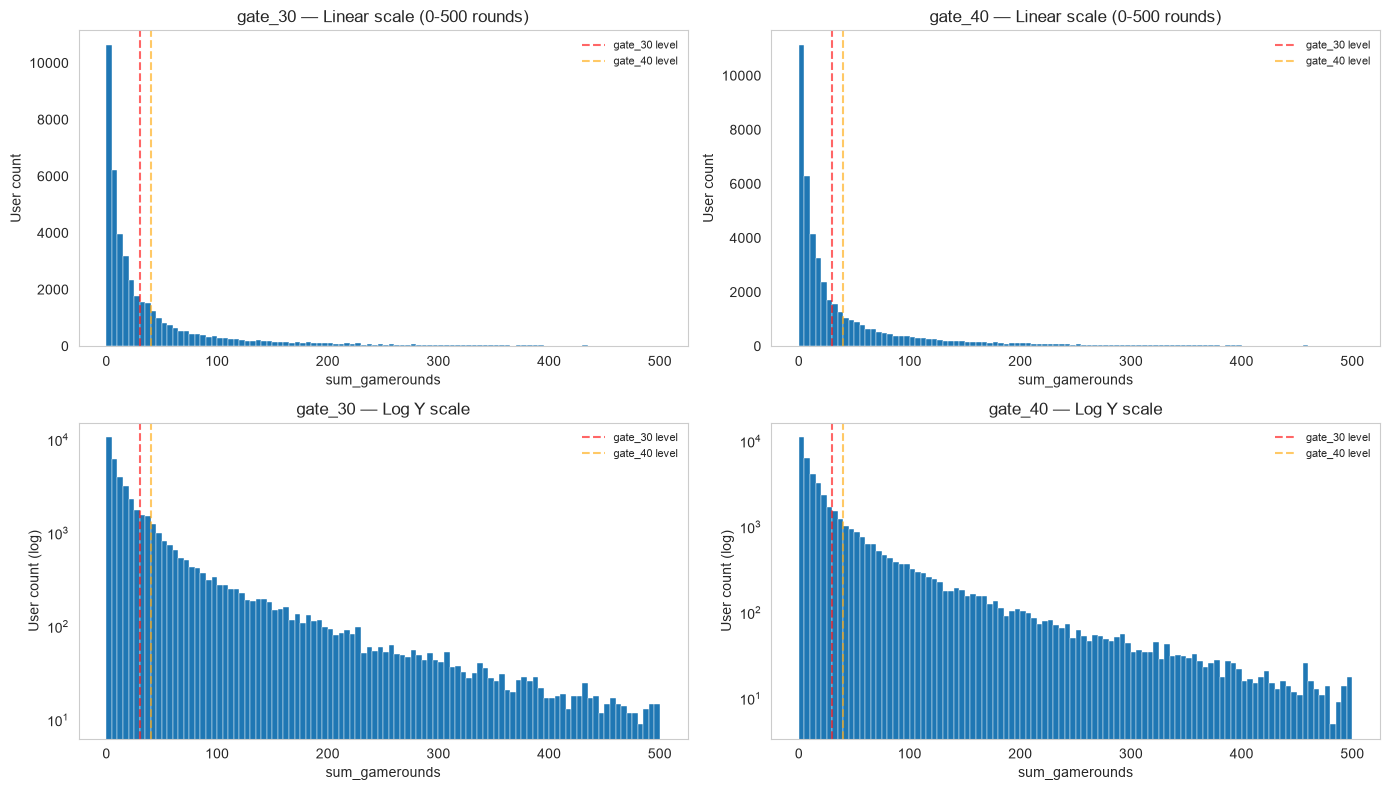

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# ---- Row 1: Linear scale ----
for i, version in enumerate(["gate_30", "gate_40"]):
    subset = df[df["version"] == version]["sum_gamerounds"]
    axes[0, i].hist(subset, bins=100, range=(0, 500), edgecolor="white", linewidth=0.3)
    axes[0, i].axvline(30, color="red", linestyle="--", alpha=0.6, label="gate_30 level")
    axes[0, i].axvline(40, color="orange", linestyle="--", alpha=0.6, label="gate_40 level")
    axes[0, i].set_title(f"{version} — Linear scale (0-500 rounds)")
    axes[0, i].set_xlabel("sum_gamerounds")
    axes[0, i].set_ylabel("User count")
    axes[0, i].grid(False)
    axes[0, i].legend(loc="upper right", fontsize=8, frameon=False)

# ---- Row 2: Log scale (Y axis) để nhìn tail ----
for i, version in enumerate(["gate_30", "gate_40"]):
    subset = df[df["version"] == version]["sum_gamerounds"]
    axes[1, i].hist(subset, bins=100, range=(0, 500), edgecolor="white", linewidth=0.3)
    axes[1, i].axvline(30, color="red", linestyle="--", alpha=0.6, label="gate_30 level")
    axes[1, i].axvline(40, color="orange", linestyle="--", alpha=0.6, label="gate_40 level")
    axes[1, i].set_yscale("log")
    axes[1, i].set_title(f"{version} — Log Y scale")
    axes[1, i].set_xlabel("sum_gamerounds")
    axes[1, i].set_ylabel("User count (log)")
    axes[1, i].grid(False)
    axes[1, i].legend(loc="upper right", fontsize=8, frameon=False)

plt.tight_layout()
plt.savefig("../reports/phase2_histogram_gamerounds.png", dpi=120, bbox_inches="tight")
plt.show()

Step 5: Pareto Analysis 

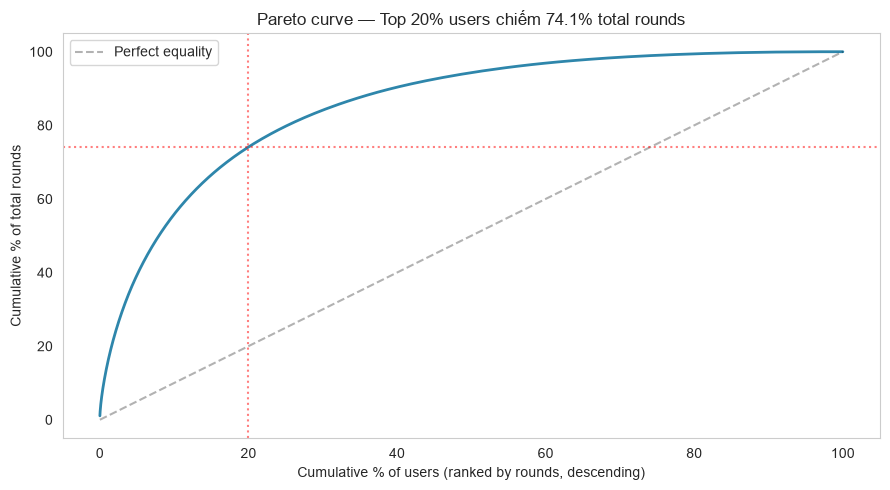

Top 1% users chiếm: 15.0% total rounds
Top 5% users chiếm:39.4% total rounds
Top 10% users chiếm: 55.8% total rounds
Top 20% users chiếm: 74.1% total rounds


In [ ]:
# Pareto: bao nhiêu % user đóng góp bao nhiêu % total rounds?
# Insight: 20% user chơi 80% rounds


sorted_rounds = df["sum_gamerounds"].sort_values(ascending=False).values
cum_rounds = np.cumsum(sorted_rounds)
cum_rounds_pct = cum_rounds / cum_rounds[-1] * 100
user_pct = np.arange(1, len(sorted_rounds) + 1) / len(sorted_rounds) * 100

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(user_pct, cum_rounds_pct, linewidth=2, color="#2E86AB")
ax.plot([0, 100], [0, 100], "k--", alpha=0.3, label="Perfect equality")
ax.axvline(20, color="red", linestyle=":", alpha=0.5)
ax.axhline(cum_rounds_pct[int(len(sorted_rounds)*0.2) - 1], color="red", linestyle=":", alpha=0.5)

pct_at_20 = cum_rounds_pct[int(len(sorted_rounds)*0.2) - 1]
ax.set_title(f"Pareto curve — Top 20% users chiếm {pct_at_20:.1f}% total rounds")
ax.set_xlabel("Cumulative % of users (ranked by rounds, descending)")
ax.set_ylabel("Cumulative % of total rounds")
ax.legend()
ax.grid(False)
plt.tight_layout()
plt.savefig("../reports/phase2_pareto.png", dpi=120, bbox_inches="tight")
plt.show()

print(f"Top 1% users chiếm: {cum_rounds_pct[int(len(sorted_rounds)*0.01) - 1]:.1f}% total rounds")
print(f"Top 5% users chiếm:{cum_rounds_pct[int(len(sorted_rounds)*0.05) - 1]:.1f}% total rounds")
print(f"Top 10% users chiếm: {cum_rounds_pct[int(len(sorted_rounds)*0.10) - 1]:.1f}% total rounds")
print(f"Top 20% users chiếm: {cum_rounds_pct[int(len(sorted_rounds)*0.20) - 1]:.1f}% total rounds")

Step 6: Zero-inflation check

In [ ]:
# Zero-inflation: % user không chơi round nào
# Mobile game thường có 5-15% "install & never play" — cần đo cụ thể

zero_stats = df.groupby("version").agg(
    n_total=("userid", "count"),
    n_zero=("sum_gamerounds", lambda x: (x == 0).sum()),
).assign(pct_zero=lambda d: (d["n_zero"] / d["n_total"] * 100).round(2))

print("Zero-play analysis by version:")
print(zero_stats)
print()

# Cross-tab với retention
zero_retention = df[df["sum_gamerounds"] == 0].groupby("version").agg(
    n_zero=("userid", "count"),
    n_r1_true=("retention_1", "sum"),
    n_r7_true=("retention_7", "sum"),
).assign(
    pct_r1=lambda d: (d["n_r1_true"] / d["n_zero"] * 100).round(2),
    pct_r7=lambda d: (d["n_r7_true"] / d["n_zero"] * 100).round(2),
)
print("Zero-play users — retention breakdown:")
print(zero_retention)

Zero-play analysis by version:
         n_total  n_zero  pct_zero
version                           
gate_30    44700    1937      4.33
gate_40    45489    2057      4.52

Zero-play users — retention breakdown:
         n_zero  n_r1_true  n_r7_true  pct_r1  pct_r7
version                                              
gate_30    1937         41         16    2.12    0.83
gate_40    2057         46         13    2.24    0.63


Step 7: Cumulative retention curve

Retention by engagement bucket × version:
                     n      r1      r7
bucket  version                       
0       gate_30   1937  0.0212  0.0083
        gate_40   2057  0.0224  0.0063
1-14    gate_30  18845  0.1578  0.0247
        gate_40  19487  0.1605  0.0240
15-29   gate_30   7262  0.5065  0.0980
        gate_40   7332  0.4944  0.0893
30-99   gate_30  10488  0.7415  0.2784
        gate_40  10265  0.7422  0.2567
100-499 gate_30   5740  0.8969  0.6937
        gate_40   5916  0.8925  0.6919
500+    gate_30    428  0.9720  0.9486
        gate_40    432  0.9769  0.9630


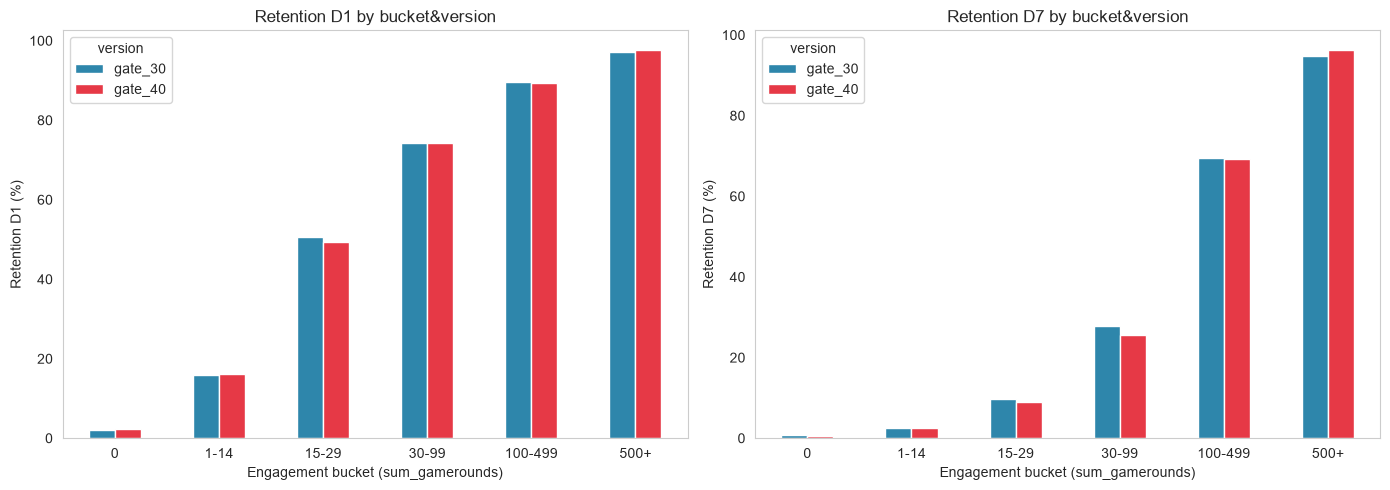

In [ ]:
# Retention rate theo bucket sum_gamerounds
# Answer: "user chơi càng nhiều thì retention càng cao"? Bao nhiêu?

# Tạo bucket (sẽ chuẩn hóa ở Phase 3, đây chỉ preview)
bins = [-1, 0, 14, 29, 99, 499, np.inf]
labels = ["0", "1-14", "15-29", "30-99", "100-499", "500+"]
df_prev = df.copy()
df_prev["bucket"] = pd.cut(df_prev["sum_gamerounds"], bins=bins, labels=labels)

retention_by_bucket = df_prev.groupby(["bucket", "version"], observed=True).agg(
    n=("userid", "count"),
    r1=("retention_1", "mean"),
    r7=("retention_7", "mean"),
).round(4)

print("Retention by engagement bucket × version:")
print(retention_by_bucket)

# Vẽ chart
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for i, metric in enumerate(["r1", "r7"]):
    pivot = retention_by_bucket[metric].unstack("version") * 100
    pivot.plot(kind="bar", ax=axes[i], color=["#2E86AB", "#E63946"])
    axes[i].set_title(f"Retention D{'1' if metric == 'r1' else '7'} by bucket&version")
    axes[i].set_ylabel(f"Retention D{'1' if metric == 'r1' else '7'} (%)")
    axes[i].set_xlabel("Engagement bucket (sum_gamerounds)")
    axes[i].legend(title="version")
    axes[i].grid(False)
    axes[i].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.savefig("../reports/phase2_retention_by_bucket.png", dpi=120, bbox_inches="tight")
plt.show()